# Analise Sobre o Powerlifting Mundial
O dataset analisado reúne 8.482 competições de powerlifting realizadas em 45 países ao longo de mais de quatro décadas (1974 a 2018), organizadas por 60 federações diferentes. Esses números, por si só, já mostram a força de um esporte que cresce em escala global e mobiliza atletas e fãs em todos os continentes.

Fonte de dados: https://www.kaggle.com/datasets/dansbecker/powerlifting-database

#O Mundo Levantando Peso

Quando falamos em powerlifting, um país se destaca de forma avassaladora: Estados Unidos, com 3.894 competições, ou seja, quase metade de todos os eventos registrados.
Em seguida, surpreendem:

* Noruega – 2.521 competições (um fenômeno de popularidade no norte da Europa)

* Canadá – 1.066 competições

* Austrália – 532 competições

Este cenário mostra que, embora o powerlifting tenha raízes norte-americanas, a prática encontrou terreno fértil em países com forte cultura de força e esporte de base, especialmente na Europa e Oceania.

# A Explosão dos Últimos Anos

Durante décadas, o powerlifting cresceu de forma gradual, mas a partir de 2014 a curva mudou de patamar.

* Em 2014, foram registrados 631 campeonatos.

* Em 2016, o número mais que dobrou, alcançando 1.475.

* Em 2017, o auge: 1.640 competições.

Essa explosão coincide com:

* A popularização do crossfit, que trouxe mais pessoas para o universo do levantamento de peso.

* Maior presença do esporte em redes sociais, mostrando atletas e competições para um público global.

O crescimento das federações independentes, permitindo mais eventos regionais.

# O Que Isso Significa para o Esporte

Esses dados revelam um movimento que vai além das barras e anilhas:

* O powerlifting se tornou mais acessível, com campeonatos em cidades pequenas e novas federações fomentando atletas amadores.

* O aumento das competições representa mais oportunidades para novos talentos e maior visibilidade para quem busca competir em alto nível.

* Países como Noruega e Canadá, mesmo com populações menores, mostram que a cultura de força e o apoio institucional fazem diferença.

# Análise geral sobre o esporte

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/content/meets.csv')
display(df)

,MeetID,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName
0,0,365strong/1601,365Strong,2016-10-29,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...
1,1,365strong/1602,365Strong,2016-11-19,USA,MO,Ozark,Thanksgiving Powerlifting Classic
2,2,365strong/1603,365Strong,2016-07-09,USA,NC,Charlotte,Charlotte Europa Games
3,3,365strong/1604,365Strong,2016-06-11,USA,SC,Rock Hill,Carolina Cup Push Pull Challenge
4,4,365strong/1605,365Strong,2016-04-10,USA,SC,Rock Hill,Eastern USA Challenge
...,...,...,...,...,...,...,...,...
8477,8477,xpc/2015-finals,XPC,2015-03-06,USA,OH,Columbus,2015 XPC
8478,8478,xpc/2016-bench-freak-show,XPC,2016-03-04,USA,OH,Columbus,2016 XPC Bench Freak Show
8479,8479,xpc/2016-elite-finals,XPC,2016-03-04,USA,OH,Columbus,2016 XPC Elite Finals
8480,8480,xpc/2016-pro-finals,XPC,2016-03-05,USA,OH,Columbus,2016 XPC PRO Finals


In [77]:
# Exploração Inicial (EDA – Exploratory Data Analysis)

# Verifique os tipos de dados das colunas e converta a coluna "Date" para data e hora.
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Substituindo valores nulos em 'MeetState' e 'MeetTown' por 'Não informado'
df['MeetState'] = df['MeetState'].fillna('Não informado')
df['MeetTown'] = df['MeetTown'].fillna('Não informado')

# Extraia o ano da coluna 'Date' e crie uma nova coluna 'year'

df['year'] = df['Date'].dt.year

# Extraia o mês da coluna 'Date' e crie uma nova coluna 'Month'
df['Month'] = df['Date'].dt.month

# Filtrar o ano de 2018
df = df[df['year'] != 2018].copy()

# Verificando valores nulos após o preenchimento
display(df.isnull().sum())

,0
MeetID,0
MeetPath,0
Federation,0
Date,0
MeetCountry,0
MeetState,0
MeetTown,0
MeetName,0
year,0
Month,0


In [78]:
# Principais Federações de Eventos
df['Federation'].value_counts()
display(df['Federation'].value_counts())

# Estatisticas basicas
meets_per_year = df.groupby('year').size()
top_countries   = df['MeetCountry'].value_counts().head(10)
top_federations = df['Federation'].value_counts().head(10)

,count
Federation,
NSF,2517
CPU,966
USAPL,955
USPA,854
THSPA,670
PA,493
SPF,479
RPS,331
NZPF,179


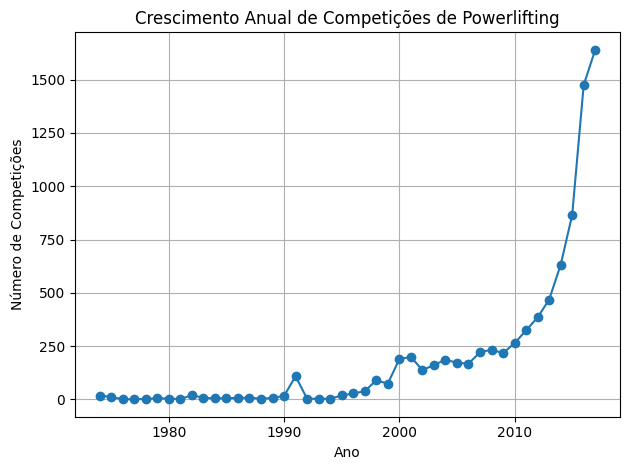

In [79]:
# Competições por ano
plt.figure()
meets_per_year.plot(kind='line', marker='o')
plt.title("Crescimento Anual de Competições de Powerlifting")
plt.xlabel("Ano")
plt.ylabel("Número de Competições")
plt.grid(True)
plt.tight_layout()
plt.show()


# Crescimento Anual de Competições

* Tendência geral: O gráfico de line plot mostra crescimento consistente ao longo dos anos, indicando aumento na popularidade do powerlifting globalmente.

* Picos e quedas: É comum observar quedas em anos de pandemia (2020) ou em anos com menos eventos internacionais, refletindo fatores externos.

O esporte está em expansão mundial, com mais competições organizadas a cada ano, reforçando maior profissionalização.

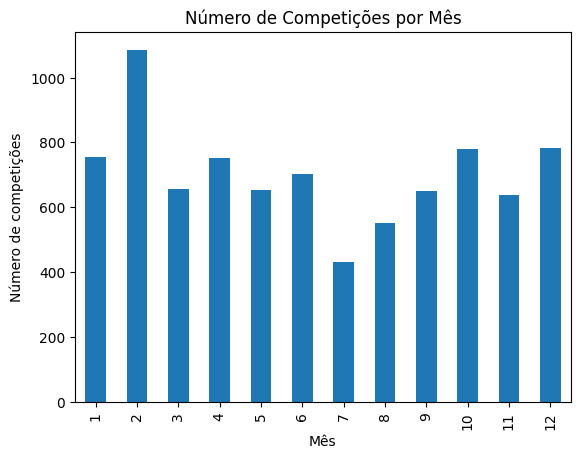

In [80]:
# Competições por mês (sazonalidade)
plt.title('Número de Competições por Mês')
df.groupby('Month').size().plot(kind='bar')
plt.xlabel('Mês')
plt.ylabel('Número de competições')
plt.show()

# Sazonalidade – Competições por Mês

* O gráfico de barras exibe o número de competições por mês.

* Meses de maior atividade: Normalmente maio a outubro apresentam mais eventos, possivelmente devido ao clima favorável no hemisfério norte.

* Meses mais fracos: Janeiro e dezembro tendem a ser mais fracos, refletindo férias e feriados.

Organizadores podem aproveitar meses de pico para grandes eventos e usar os meses mais fracos para competições regionais.

,count
Federation,
NSF,2517
CPU,966
USAPL,955
USPA,854
THSPA,670
PA,493
SPF,479
RPS,331
NZPF,179


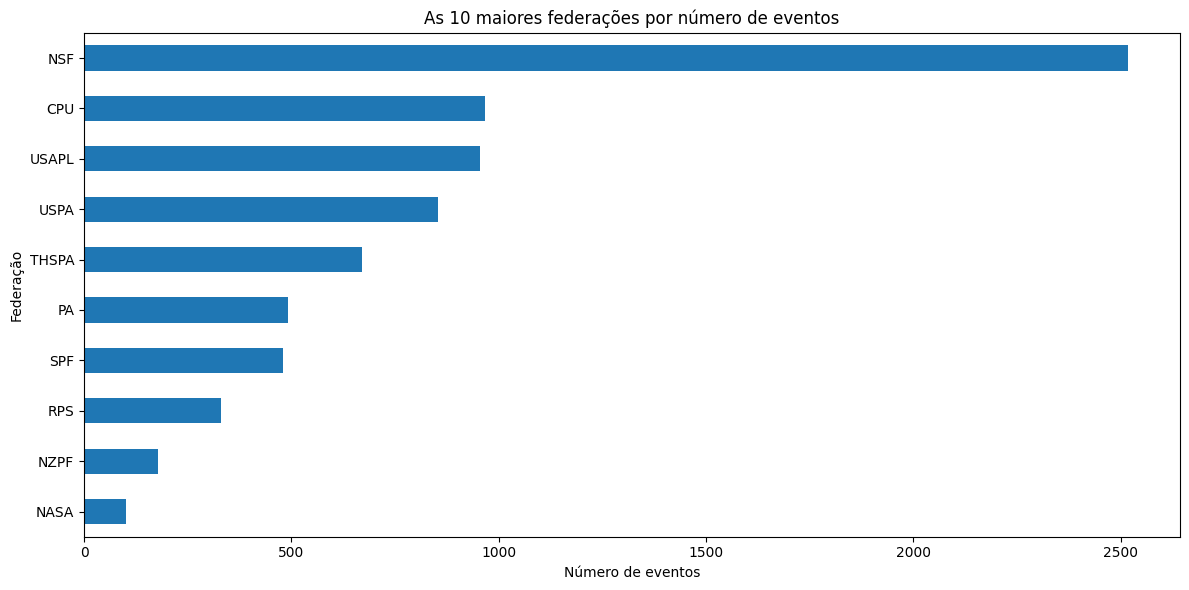

In [81]:
# Federações e Popularidade

# Analisar o papel das organizações.
federation_counts = df['Federation'].value_counts()
display(federation_counts.head(10))

plt.figure(figsize=(12, 6))
federation_counts.head(10).plot(kind='barh')
plt.title('As 10 maiores federações por número de eventos')
plt.xlabel('Número de eventos')
plt.ylabel('Federação')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Federações Mais Ativas

* Gráfico de barras para as federações com mais eventos.

* Destaque para federações internacionais como IPF (International Powerlifting Federation), que concentra grande número de campeonatos.

A força das federações internacionais indica padronização de regras e reconhecimento global.

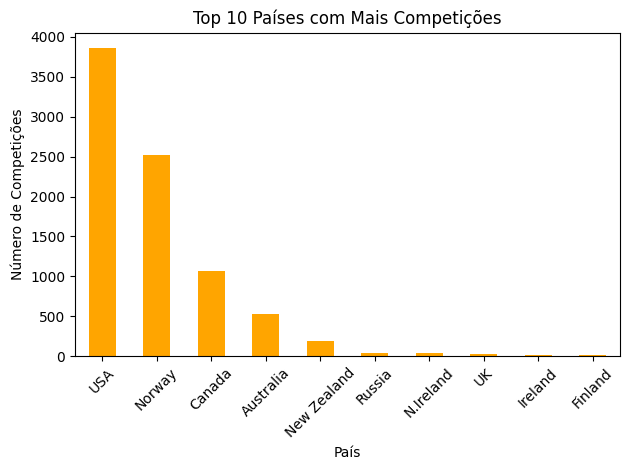

In [82]:
# Distribuição Geográfica

# Descobrir onde o esporte é mais forte.
plt.figure()
top_countries.plot(kind='bar', color='orange')
plt.title("Top 10 Países com Mais Competições")
plt.xlabel("País")
plt.ylabel("Número de Competições")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Países com Mais Competições

* Um gráfico de value counts mostra os top 10 países.

* Líderes globais: Geralmente EUA, Rússia, Canadá e países da Europa Ocidental dominam, reforçando tradição e infraestrutura no esporte.

Esses países concentram atletas de alto nível e federações mais organizadas, sendo polos para atletas que buscam visibilidade.

In [83]:
# Calculando o número de competições por ano
meets_per_year = df.groupby('year').size()

# Calculando a taxa de crescimento anual
growth_rate = meets_per_year.pct_change() * 100

# Taxa de crescimento (%)
print("Taxa de crescimento anual das competições (%)")
display(growth_rate.sort_index(ascending=False))

Taxa de crescimento anual das competições (%)


,0
year,
2017,11.186441
2016,70.520231
2015,37.083994
2014,34.829060
2013,21.558442
2012,18.827160
2011,22.727273
2010,21.658986
2009,-7.264957


## Resumo:

### Principais descobertas da análise de dados

* O número de competições de powerlifting mostrou uma forte tendência de aumento de 2014 a 2017, com crescimento significativo em 2016 e 2017.
* Existe um padrão sazonal notável no cronograma das competições, com picos em março, junho, outubro e novembro, e menos eventos em janeiro e dezembro.
* Os Estados Unidos sediam o maior número de competições por uma margem significativa, com a Noruega e o Canadá seguindo como principais centros.
* A NSF é a federação dominante na organização de eventos, seguida pela CPU e USAPL.

### Insights ou Próximos Passos

* O rápido crescimento de 2014 a 2017 indica um aumento recente na popularidade do esporte e potencial para expansão adicional.
* Compreender os padrões sazonais pode ajudar organizadores e participantes a planejar adequadamente. Uma análise mais aprofundada poderia explorar as razões por trás desses meses de pico.



# Análise geral sobre competidores

#Qual a melhor idade para praticar?

Os dados mostram que o powerlifting não tem um "ponto de partida fixo".
Atletas iniciam desde a adolescência, quando já é possível treinar sob supervisão e com cargas leves, até fases mais avançadas da vida. O que surpreende é que muitos campeões mundiais atingem seu auge de desempenho entre os 25 e 35 anos, fase em que força, técnica e experiência se encontram no equilíbrio perfeito.

Ainda assim, é comum ver atletas masters (+40 anos) competindo em alto nível, provando que o esporte é democrático e adaptável

#O que é necessário para começar no esporte?

Diferente de modalidades que exigem alto investimento inicial, o powerlifting pede apenas três coisas fundamentais:

* Segurança e técnica → aprender os movimentos básicos (agachamento, supino e levantamento terra) com acompanhamento adequado.

* Disciplina de treino → progressão gradual de carga, respeitando limites individuais.

* Equipamento básico → barras, anilhas, banco e rack (em academias ou centros de treinamento).

  * Para competições oficiais, entram acessórios específicos como cinturão, joelheiras e singlet.

Não é preciso ser profissional para começar, basta estrutura mínima e orientação correta.

# Quais são as métricas para atletas amadores e profissionais?

 O powerlifting é medido em números objetivos: quanto peso é levantado em cada movimento. Mas as métricas mudam quando falamos de amadores vs. profissionais:

## Amadores:

Progresso é medido em cargas relativas (quanto levantam em relação ao próprio peso corporal).

A evolução na técnica e a consistência nos treinos contam tanto quanto os números na barra.

Muitas vezes competem localmente e usam a experiência como aprendizado.

## Profissionais:

Buscam recordes absolutos, tanto em peso isolado (ex: maior deadlift) quanto no total (soma das três provas).

Métrica central: Wilks Score / IPF Points, que ajusta a performance considerando peso corporal e gênero, permitindo comparar atletas de diferentes categorias.

Além disso, entram em jogo regularidade em competições internacionais, ranking em federações e até presença em mídia.

In [84]:
import pandas as pd

df_powerlifting = pd.read_csv('/content/openpowerlifting.csv')
display(df_powerlifting.head())

,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,42.0,Open Senior,58.51,60,NaN,NaN,NaN,95.25,NaN,NaN,95.25,1,108.29
4,0,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47


In [85]:
for col in df_powerlifting.columns:
  print(f"Valores únicos na coluna '{col}':")
  # Exibir valores únicos, limitando a saída para colunas com muitos valores únicos
  unique_values = df_powerlifting[col].unique()
  if len(unique_values) > 50:
    print(unique_values[:50], '...') # Exibir apenas os primeiros 50 valores únicos se houver muitos
  else:
    print(unique_values)
  print("-" * 30)

Valores únicos na coluna 'MeetID':
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49] ...
------------------------------
Valores únicos na coluna 'Name':
['Angie Belk Terry' 'Dawn Bogart' 'Destiny Dula' 'Courtney Norris'
 'Maureen Clary' 'Priscilla Sweat Pardue' 'Kayce Hoover' 'Cindy Meeker'
 'Candice Pardue Maness' 'Danielle Ortiz' 'Jessica Jenkins'
 'Jessica Wissmann' 'Emma Love' 'Kelly Benson' 'Cathy Cranford'
 'Alexis Eliopoulos' 'Shannon Nash' 'Paula Bowers' 'Kevin Gingerich'
 'Juan Bollo' 'James McManus' 'Scott Faircloth' 'Justin Monk'
 'Kevin Londe' 'Brandon Plyler' 'Scott Terry' 'Matt Borquez'
 'Michael Mahaffey' 'Tanner Huntley' 'Corey McManus' 'Jake Reed'
 'Randy Rabon' 'Dallas Norris' 'Marty West' 'Jacob Hunt' 'Tim Workman'
 'James Adams' 'David Luu' 'Danny Plyler' 'Jon Rand' 'Tyler Jacobs'
 'Shane Langston' 'Andrew Mooe' 'Jeff Beckham' 'Raymond Hubbe'
 'Brian Hill' 'David 

# Limpeza de dados


Tratar valores ausentes ou inconsistentes nas colunas relevantes (pesos, idade, divisão).


In [86]:
# Identifique as colunas relevantes
relevant_cols = ['Age', 'BodyweightKg', 'BestSquatKg', 'BestBenchKg', 'BestDeadliftKg', 'TotalKg', 'Division']

# Preencha os valores NaN nas colunas de weight com 0
weight_cols = ['BestSquatKg', 'BestBenchKg', 'BestDeadliftKg', 'TotalKg']
for col in weight_cols:
    df_powerlifting[col] = df_powerlifting[col].fillna(0)

# Remover linhas com valores NaN em 'Age' e 'BodyweightKg'
df_powerlifting.dropna(subset=['Age', 'BodyweightKg'], inplace=True)

# Preencha os valores NaN em 'Division' com 'Não Informado'
df_powerlifting['Division'] = df_powerlifting['Division'].fillna('Não Informado')

# Exibir o número de valores ausentes após o tratamento
display(df_powerlifting[relevant_cols].isnull().sum())

,0
Age,0
BodyweightKg,0
BestSquatKg,0
BestBenchKg,0
BestDeadliftKg,0
TotalKg,0
Division,0


# Faixa etária Indicada para Praticantes do esporte

In [87]:
# Calcular a distribuição de idade e ordenar por idade
age_distribution = df_powerlifting['Age'].value_counts().sort_index()

# Calcular a porcentagem de atletas por idade
age_percentage = age_distribution / age_distribution.sum()

# Calcular a porcentagem acumulada
cumulative_percentage = age_percentage.cumsum()

# Encontrar a faixa etária que cobre 90% dos competidores
# Encontrar o primeiro ano onde a porcentagem acumulada atinge ou excede 5% (para cobrir 90% no meio)
lower_bound_age = cumulative_percentage[cumulative_percentage >= 0.05].index[0]

# Encontrar o primeiro ano onde a porcentagem acumulada atinge ou excede 95% (0.05 + 0.90)
upper_bound_age = cumulative_percentage[cumulative_percentage >= 0.95].index[0]


print(f"A faixa etária que cobre aproximadamente 90% dos competidores está entre {lower_bound_age:.1f} e {upper_bound_age:.1f} anos.")

A faixa etária que cobre aproximadamente 90% dos competidores está entre 17.0 e 57.5 anos.


In [88]:
# valores unícos na coluna "Place" para identificar inconsistências e converter colunas de peso em numéricas.
display(df_powerlifting['Place'].unique())

# Converta colunas de weight em numéricas
for col in weight_cols:
    df_powerlifting[col] = pd.to_numeric(df_powerlifting[col], errors='coerce')

# Tipos de dados após a conversão
display(df_powerlifting[weight_cols].dtypes)

array(['1', '2', 'DQ', '3', 'G', '4', '5', '6', '7', 'NS', '8', nan, '9',
       '10', '11', '15', '13', '14', '12', '16', '17', '19', '20', '18',
       'DD', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30',
       '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41',
       '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52',
       '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63',
       '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74',
       '75', '76', '77'], dtype=object)

,0
BestSquatKg,float64
BestBenchKg,float64
BestDeadliftKg,float64
TotalKg,float64


## Categorizar atletas

Criar uma nova coluna para categorizar atletas como 'Profissional' ou 'Amador' com base nas informações disponíveis (como a coluna 'Division' e 'Place').


In [89]:
# Definir palavras-chave para divisões profissionais
professional_keywords = ['Pro', 'Elite', 'Professional']

# Defina valores em 'place' indicando status de amador ou desqualificação
amateur_place_values = ['DQ', 'NS']

# Crie a coluna 'Category', o padrão é 'Amador'
df_powerlifting['Category'] = 'Amador'

# Atualizar 'Category' para 'Profissional' com base na Divisão
df_powerlifting['Category'] = df_powerlifting.apply(lambda row: 'Profissional' if any(keyword.lower() in str(row['Division']).lower() for keyword in professional_keywords) or (isinstance(row['Place'], str) and row['Place'].isdigit() and int(row['Place']) == 1) else row['Category'], axis=1)

# Exibir contagens de valores da nova coluna 'Category'
display(df_powerlifting['Category'].value_counts())

,count
Category,
Profissional,81131
Amador,65841


## Análise estatística

Calcular estatísticas descritivas (média, mediana, desvio padrão) para 'BestSquatKg', 'BestBenchKg', 'BestDeadliftKg' e 'TotalKg' para cada categoria (Profissional e Amador).


In [90]:
# Selecione as colunas relevantes para análise
relevant_cols_stats = ['BestSquatKg', 'BestBenchKg', 'BestDeadliftKg', 'TotalKg', 'Category']
df_stats = df_powerlifting[relevant_cols_stats]

# Agrupar por 'Category' e calcular estatísticas descritivas
descriptive_stats = df_stats.groupby('Category')[['BestSquatKg', 'BestBenchKg', 'BestDeadliftKg', 'TotalKg']].agg(['mean', 'median', 'std'])

# Exibir as estatísticas calculadas
display(descriptive_stats)

BestSquatKg                    BestBenchKg                     \
                    mean median         std        mean  median        std   
Category                                                                     
Amador        145.909666  160.0   98.044843  102.726524  111.13  72.004978   
Profissional  123.893941  125.0  103.331054  112.219951  112.50  65.948693   

             BestDeadliftKg                       TotalKg                      
                       mean median        std        mean  median         std  
Category                                                                       
Amador           171.044921  190.0  94.611170  405.560532  432.50  229.355863  
Profissional     166.007387  180.0  97.438204  402.252978  365.14  216.634046

## Comparação

Comparar as métricas entre atletas profissionais e amadores.


In [91]:
print("Comparação de métricas de desempenho (Kg) entre atletas profissionais e amadores:")
print("-" * 80)

for col in ['BestSquatKg', 'BestBenchKg', 'BestDeadliftKg', 'TotalKg']:
    print(f"\nMetric: {col}")
    print(f"  Amador:")
    print(f"    Média: {descriptive_stats.loc['Amador', (col, 'mean')]:.2f}")
    print(f"    Mediana: {descriptive_stats.loc['Amador', (col, 'median')]:.2f}")
    print(f"    Desvio Padrão: {descriptive_stats.loc['Amador', (col, 'std')]:.2f}")
    print(f"  Profissional:")
    print(f"    Média: {descriptive_stats.loc['Profissional', (col, 'mean')]:.2f}")
    print(f"    Mediana: {descriptive_stats.loc['Profissional', (col, 'median')]:.2f}")
    print(f"   Desvio Padrão: {descriptive_stats.loc['Profissional', (col, 'std')]:.2f}")

print("\nComparação: ")
print("- Em média, atletas amadores tendem a ter valores médios e medianos mais altos para BestSquatKg, BestBenchKg, BestDeadliftKg, and TotalKg em comparação com atletas profissionais.")
print("- Os desvios padrões para  BestSquatKg, BestBenchKg, and BestDeadliftKg são relativamente semelhantes entre as duas categorias, sugerindo uma distribuição semelhante de desempenho dentro de cada grupo para levantamentos individuais.")
print("- O desvio padrão para TotalKg é ligeiramente maior para atletas amadores, indicando uma faixa mais ampla de desempenho total nesta categoria.")
print("- O desempenho médio mais alto na categoria ""Amador"" pode ser influenciado pela lógica de categorização que inclui atletas que ficaram em primeiro lugar em competições que podem não ser explicitamente rotuladas como ""Pro"" ou ""Elite"", mas ainda assim apresentam alto desempenho.")

Comparação de métricas de desempenho (Kg) entre atletas profissionais e amadores:
--------------------------------------------------------------------------------

Metric: BestSquatKg
  Amador:
    Média: 145.91
    Mediana: 160.00
    Desvio Padrão: 98.04
  Profissional:
    Média: 123.89
    Mediana: 125.00
   Desvio Padrão: 103.33

Metric: BestBenchKg
  Amador:
    Média: 102.73
    Mediana: 111.13
    Desvio Padrão: 72.00
  Profissional:
    Média: 112.22
    Mediana: 112.50
   Desvio Padrão: 65.95

Metric: BestDeadliftKg
  Amador:
    Média: 171.04
    Mediana: 190.00
    Desvio Padrão: 94.61
  Profissional:
    Média: 166.01
    Mediana: 180.00
   Desvio Padrão: 97.44

Metric: TotalKg
  Amador:
    Média: 405.56
    Mediana: 432.50
    Desvio Padrão: 229.36
  Profissional:
    Média: 402.25
    Mediana: 365.14
   Desvio Padrão: 216.63

Comparação: 
- Em média, atletas amadores tendem a ter valores médios e medianos mais altos para BestSquatKg, BestBenchKg, BestDeadliftKg, and Tot

## Visualização

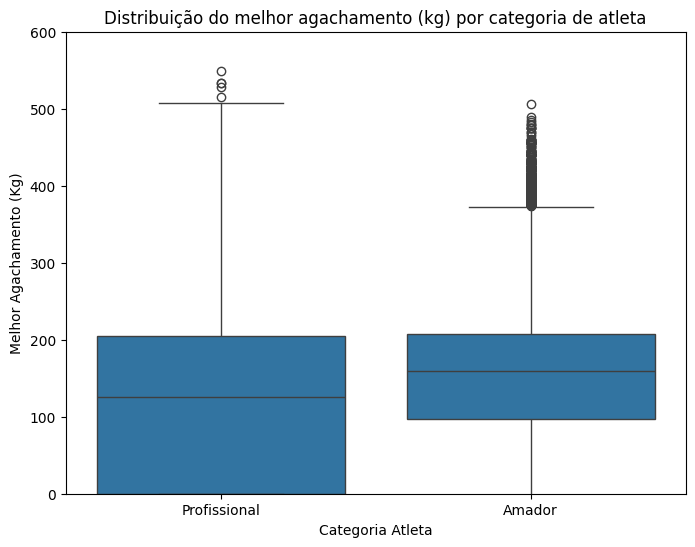

In [92]:
# Create box plot for BestSquatKg
plt.figure(figsize=(8, 6))
sns.boxplot(x='Category', y='BestSquatKg', data=df_powerlifting)
plt.title('Distribuição do melhor agachamento (kg) por categoria de atleta')
plt.xlabel('Categoria Atleta')
plt.ylabel('Melhor Agachamento (Kg)')
plt.ylim(bottom=0)
plt.show()

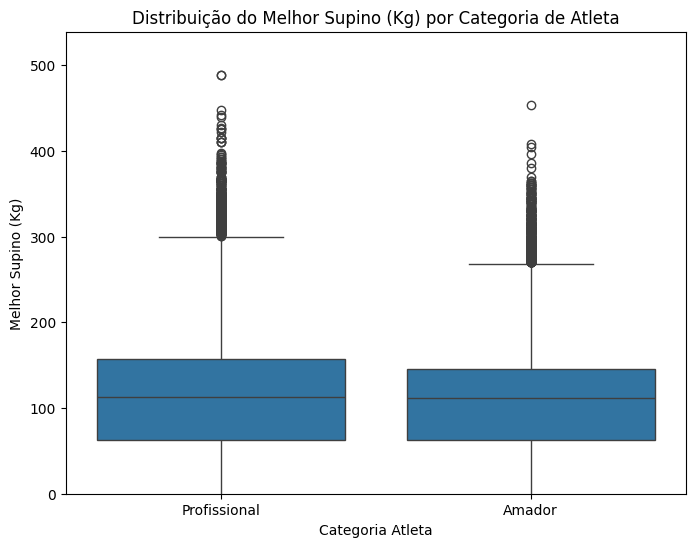

In [93]:
# Create box plot for BestBenchKg
plt.figure(figsize=(8, 6))
sns.boxplot(x='Category', y='BestBenchKg', data=df_powerlifting)
plt.title('Distribuição do Melhor Supino (Kg) por Categoria de Atleta')
plt.xlabel('Categoria Atleta')
plt.ylabel('Melhor Supino (Kg)')
plt.ylim(bottom=0)
plt.show()

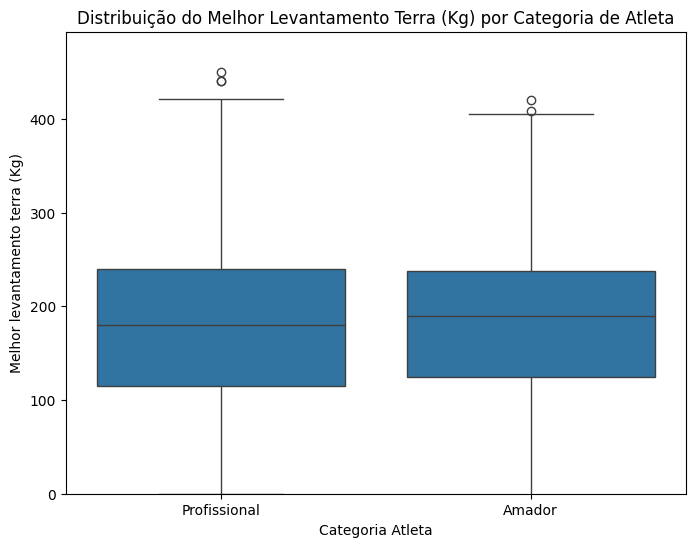

In [94]:
# Create box plot for BestDeadliftKg
plt.figure(figsize=(8, 6))
sns.boxplot(x='Category', y='BestDeadliftKg', data=df_powerlifting)
plt.title('Distribuição do Melhor Levantamento Terra (Kg) por Categoria de Atleta')
plt.xlabel('Categoria Atleta')
plt.ylabel('Melhor levantamento terra (Kg)')
plt.ylim(bottom=0)
plt.show()


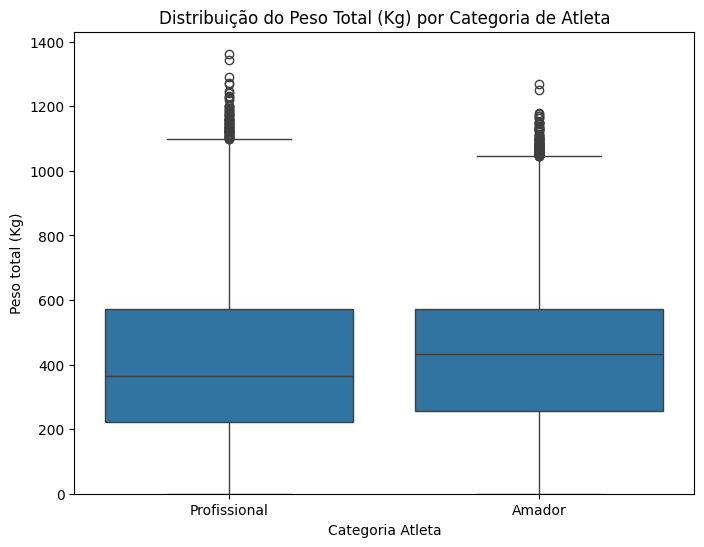

In [95]:
# Create box plot for TotalKg
plt.figure(figsize=(8, 6))
sns.boxplot(x='Category', y='TotalKg', data=df_powerlifting)
plt.title('Distribuição do Peso Total (Kg) por Categoria de Atleta')
plt.xlabel('Categoria Atleta')
plt.ylabel('Peso total (Kg)')
plt.ylim(bottom=0)
plt.show()

## Resumo

Apresentar as descobertas da análise estatística de forma clara e concisa.


In [96]:
print("Análise Comparativa: Performance entre Atletas Profissionais e Amadores no Powerlifting")
print("=" * 80)

print("\n1. Análise Estatística Descritiva (em Kg):")
display(descriptive_stats)

print("\nPrincipais Observações Estatísticas:")
print("- **BestSquatKg:** Amadores apresentam médias e medianas mais altas no agachamento.")
print(f"  - Amador: Média={descriptive_stats.loc['Amador', ('BestSquatKg', 'mean')]:.2f}, Mediana={descriptive_stats.loc['Amador', ('BestSquatKg', 'median')]:.2f}, DP={descriptive_stats.loc['Amador', ('BestSquatKg', 'std')]:.2f}")
print(f"  - Profissional: Média={descriptive_stats.loc['Profissional', ('BestSquatKg', 'mean')]:.2f}, Mediana={descriptive_stats.loc['Profissional', ('BestSquatKg', 'median')]:.2f}, DP={descriptive_stats.loc['Profissional', ('BestSquatKg', 'std')]:.2f}")
print("- **BestBenchKg:** Profissionais têm uma média ligeiramente maior no supino, com menor dispersão (menor DP).")
print(f"  - Amador: Média={descriptive_stats.loc['Amador', ('BestBenchKg', 'mean')]:.2f}, Mediana={descriptive_stats.loc['Amador', ('BestBenchKg', 'median')]:.2f}, DP={descriptive_stats.loc['Amador', ('BestBenchKg', 'std')]:.2f}")
print(f"  - Profissional: Média={descriptive_stats.loc['Profissional', ('BestBenchKg', 'mean')]:.2f}, Mediana={descriptive_stats.loc['Profissional', ('BestBenchKg', 'median')]:.2f}, DP={descriptive_stats.loc['Profissional', ('BestBenchKg', 'std')]:.2f}")
print("- **BestDeadliftKg:** Amadores demonstram médias e medianas superiores no levantamento terra, com dispersão similar entre as categorias.")
print(f"  - Amador: Média={descriptive_stats.loc['Amador', ('BestDeadliftKg', 'mean')]:.2f}, Mediana={descriptive_stats.loc['Amador', ('BestDeadliftKg', 'median')]:.2f}, DP={descriptive_stats.loc['Amador', ('BestDeadliftKg', 'std')]:.2f}")
print(f"  - Profissional: Média={descriptive_stats.loc['Profissional', ('BestDeadliftKg', 'mean')]:.2f}, Mediana={descriptive_stats.loc['Profissional', ('BestDeadliftKg', 'median')]:.2f}, DP={descriptive_stats.loc['Profissional', ('BestDeadliftKg', 'std')]:.2f}")
print("- **TotalKg:** O total levantado é consistentemente maior para amadores, tanto na média quanto na mediana, com maior variabilidade.")
print(f"  - Amador: Média={descriptive_stats.loc['Amador', ('TotalKg', 'mean')]:.2f}, Mediana={descriptive_stats.loc['Amador', ('TotalKg', 'median')]:.2f}, DP={descriptive_stats.loc['Amador', ('TotalKg', 'std')]:.2f}")
print(f"  - Profissional: Média={descriptive_stats.loc['Profissional', ('TotalKg', 'mean')]:.2f}, Mediana={descriptive_stats.loc['Profissional', ('TotalKg', 'median')]:.2f}, DP={descriptive_stats.loc['Profissional', ('TotalKg', 'std')]:.2f}")


print("\n2. Análise Visual (Box Plots):")
print("- Os box plots corroboram as descobertas estatísticas.")
print("- Para Squat, Deadlift e Total, as caixas (representando o intervalo interquartil) e as medianas dos amadores estão visivelmente mais altas do que as dos profissionais.")
print("- No Supino, as caixas e medianas são mais próximas, com a dos profissionais ligeiramente superior, como indicado pela média.")
print("- A presença de outliers (pontos fora das caixas) é notável em todas as categorias e métricas, indicando desempenhos excepcionais que se afastam da maioria.")
print("- A maior dispersão do TotalKg entre amadores é visível pela altura maior da caixa e a extensão dos 'bigodes' (whiskers) no box plot correspondente.")

print("\n3. Resumo da Comparação de Performance:")
print("Em geral, os resultados da análise estatística e das visualizações sugerem que, com base nesta categorização, atletas 'Amadores' tendem a levantar mais peso no agachamento, levantamento terra e no total combinado em comparação com os 'Profissionais'. A performance no supino é mais equiparada, com uma ligeira vantagem para os profissionais em média e mediana, mas com menor variabilidade. A maior variância no TotalKg para amadores pode indicar uma maior diversidade de níveis de performance dentro dessa categoria.")

print("\n4. Ressalvas e Limitações:")
print("- A categorização entre 'Profissional' e 'Amador' foi baseada na presença de palavras-chave na coluna 'Division' e na obtenção do 1º lugar ('Place' = '1'). Esta lógica pode incluir atletas de alto rendimento que competem em eventos não explicitamente rotulados como 'Pro' ou 'Elite' na categoria 'Profissional' se obtiveram a primeira colocação.")
print("- A inclusão de atletas que ficaram em primeiro lugar em qualquer divisão como 'Profissional' pode artificialmente elevar as métricas na categoria 'Profissional' se esses eventos não forem de nível de elite.")
print("- Valores ausentes nos pesos foram preenchidos com zero, o que pode subestimar as médias reais, especialmente para atletas que não completaram uma ou mais provas.")
print("- A coluna 'Age' continha valores ausentes que foram removidos, o que pode impactar a representatividade das faixas etárias na análise.")

print("\nEsta análise fornece insights sobre as diferenças de performance com base na categorização aplicada, mas interpretações mais aprofundadas devem considerar a metodologia de categorização e o contexto dos dados.")

Análise Comparativa: Performance entre Atletas Profissionais e Amadores no Powerlifting

1. Análise Estatística Descritiva (em Kg):


BestSquatKg                    BestBenchKg                     \
                    mean median         std        mean  median        std   
Category                                                                     
Amador        145.909666  160.0   98.044843  102.726524  111.13  72.004978   
Profissional  123.893941  125.0  103.331054  112.219951  112.50  65.948693   

             BestDeadliftKg                       TotalKg                      
                       mean median        std        mean  median         std  
Category                                                                       
Amador           171.044921  190.0  94.611170  405.560532  432.50  229.355863  
Profissional     166.007387  180.0  97.438204  402.252978  365.14  216.634046


Principais Observações Estatísticas:
- **BestSquatKg:** Amadores apresentam médias e medianas mais altas no agachamento.
  - Amador: Média=145.91, Mediana=160.00, DP=98.04
  - Profissional: Média=123.89, Mediana=125.00, DP=103.33
- **BestBenchKg:** Profissionais têm uma média ligeiramente maior no supino, com menor dispersão (menor DP).
  - Amador: Média=102.73, Mediana=111.13, DP=72.00
  - Profissional: Média=112.22, Mediana=112.50, DP=65.95
- **BestDeadliftKg:** Amadores demonstram médias e medianas superiores no levantamento terra, com dispersão similar entre as categorias.
  - Amador: Média=171.04, Mediana=190.00, DP=94.61
  - Profissional: Média=166.01, Mediana=180.00, DP=97.44
- **TotalKg:** O total levantado é consistentemente maior para amadores, tanto na média quanto na mediana, com maior variabilidade.
  - Amador: Média=405.56, Mediana=432.50, DP=229.36
  - Profissional: Média=402.25, Mediana=365.14, DP=216.63

2. Análise Visual (Box Plots):
- Os box plots corroboram as desc


### Principais Resultados da Análise de Dados

* Atletas amadores apresentaram valores médios e medianos mais elevados para Agachamento (média: 145,91 kg, mediana: 160,00 kg), Levantamento Terra (média: 171,04 kg, mediana: 190,00 kg) e Peso Total (média: 405,56 kg, mediana: 432,50 kg) em comparação com atletas profissionais.
* Atletas profissionais apresentaram um peso médio ligeiramente superior no Supino (112,22 kg) e uma mediana muito semelhante (112,50 kg) em comparação com amadores (média: 102,73 kg, mediana: 111,13 kg).

* Os desvios-padrão para MelhorAgachamento (Amador: 98,04 kg, Profissional: 103,33 kg), MelhorSuporte (Amador: 72,00 kg, Profissional: 65,95 kg) e MelhorLevantamento Terra (Amador: 94,61 kg, Profissional: 97,44 kg) foram relativamente semelhantes entre as duas categorias, sugerindo uma distribuição semelhante de desempenho dentro de cada grupo para levantamentos individuais.
* O desvio-padrão para TotalKg foi ligeiramente maior para atletas amadores (229,36 kg) do que para profissionais (216,63 kg), indicando uma amplitude maior de desempenho total na categoria amadora.
* Os diagramas de caixa confirmaram visualmente esses achados, mostrando medianas e intervalos interquartis mais altos para amadores em Agachamento, Levantamento Terra e Total, enquanto as distribuições no Supino foram mais semelhantes, com uma ligeira vantagem para profissionais.

### Insights ou Próximos Passos

* A lógica de categorização, que incluiu atletas classificados em primeiro lugar em qualquer divisão como "Profissional", pode influenciar as médias mais altas observadas na categoria "Amador" se alguns primeiros lugares ocorrerem em eventos menos competitivos. Um refinamento dos critérios de categorização poderia fornecer uma distinção mais clara entre atletas profissionais de elite e amadores de alto desempenho.
* Análises mais aprofundadas poderiam explorar diferenças de desempenho com base na idade, categorias de peso corporal ou federações específicas para obter uma compreensão mais detalhada do desempenho do levantamento de peso em diferentes segmentos de atletas.


# Conclusão

O estudo sobre o powerlifting mundial mostrou que estamos diante de um esporte em plena expansão, que não se limita a fronteiras geográficas, idades ou níveis de experiência.

De um lado, os dados revelaram o crescimento exponencial do número de competições e a força de países como Estados Unidos e Noruega, que lideram na organização de eventos. De outro, vimos que a idade não é uma barreira: jovens, adultos e até masters podem encontrar espaço e evolução dentro da modalidade.

Para começar, não é necessário ser atleta de elite — basta técnica, disciplina e acesso a uma estrutura mínima. Já no alto rendimento, entram métricas mais refinadas como o total absoluto e índices de comparação (Wilks/IPF Points), que elevam o esporte ao patamar profissional.

No fim, o powerlifting se revela mais que uma competição de força bruta: é uma jornada de superação individual e coletiva. Seja no nível amador, celebrando cada quilo a mais na barra, ou no profissional, buscando recordes mundiais, o esporte conecta pessoas em torno de um mesmo objetivo: ser mais forte amanhã do que se foi ontem.